# 6교시 | ViT(Vision Transformer)와 이미지 토큰화
**환경**: Google Colab | **방법**: 이론 + 실습

---

## 학습 목표

- ViT(Vision Transformer)가 이미지를 패치로 분할하여 벡터 시퀀스로 변환하는 과정을 설명한다.
- **해상도** 변화가 토큰 수와 연산량에 미치는 영향을 수치로 계산한다.
- 고해상도 VLM(Vision Language Model)에서 동적 고해상도 처리가 필요한 이유를 이해한다.

### 처음 읽는 분을 위한 안내

- 이번 교시를 한 줄로 보면: 이미지를 텍스트처럼 토큰 시퀀스로 바꾸어 Transformer가 처리하게 만드는 아이디어를 배우는 시간이다.
- 처음에는 여기까지 이해하면 충분하다: 이미지는 작은 패치로 잘린 뒤 각 패치가 하나의 토큰처럼 다뤄진다고 이해하면 된다.
- 헷갈려도 괜찮은 부분: 패치 수 계산이나 Attention 비용 증가는 처음엔 숫자가 많아 보일 수 있다. 먼저 "해상도가 높을수록 토큰 수가 빠르게 늘어난다"는 감을 잡는 것이 중요하다.

### 용어 미니사전

| 용어 | 아주 쉽게 말하면 |
|---|---|
| Patch | 이미지를 일정한 크기로 자른 작은 조각 |
| Patch Token | 각 패치를 벡터로 바꾼 뒤 얻는 이미지 토큰 |
| CLS Token | 이미지 전체를 대표하도록 붙이는 특별한 토큰 |
| Resolution | 이미지의 가로·세로 크기 |
| ViT(Vision Transformer) | 이미지를 패치 토큰 시퀀스로 처리하는 Transformer |
| Dynamic High Resolution | 전체 보기와 확대 보기를 함께 쓰는 방식 |

---

## 이론

### 이미지를 LLM에 입력하는 문제

LLM은 벡터 시퀀스를 입력으로 받는다. 이미지는 픽셀 격자인데, 이를 어떻게 "토큰 시퀀스"로 변환할 수 있을까?

이번 차시의 핵심은 아래 한 문장으로 요약할 수 있다.

> ViT는 이미지를 작은 패치들로 나눈 뒤, 각 패치를 텍스트의 토큰처럼 취급한다.

즉, 텍스트에서 문장을 단어 토큰의 나열로 바꾸듯이, ViT는 이미지를 패치 토큰의 나열로 바꾼다.  
이렇게 해야 Transformer가 이미지를 텍스트와 비슷한 방식으로 처리할 수 있다.

**초기 시도: CNN 특징 추출**

- ResNet 등으로 이미지 → 고정 크기 특징 벡터(feature map) 추출
- 하지만 Transformer와의 통합이 매끄럽지 않고, 위치 정보 활용이 제한적

**ViT의 해결책: 이미지를 "패치 토큰"으로 분할**

이미지를 고정 크기 패치로 잘라 각 패치를 하나의 토큰처럼 취급한다.

여기서 중요한 포인트는, 패치 하나가 "작은 이미지 조각"이면서 동시에 모델 입장에서는 "하나의 입력 단위"라는 점이다.  
즉, 텍스트의 토큰 하나가 단어 조각을 담듯이, 이미지의 패치 하나는 국소 시각 정보를 담는다.

### ViT (Vision Transformer, 2020)

Dosovitskiy et al. *"An Image is Worth 16×16 Words"* (ICLR 2021)

**처리 흐름**

```
원본 이미지 (224×224×3)
  ↓ 패치 분할 (16×16 크기)
196개 패치 (14×14 격자)
  ↓ 각 패치를 Linear Projection
196개 패치 임베딩 벡터 (각 768차원)
  ↓ [CLS] 토큰 추가
197개 토큰 시퀀스
  ↓ Positional Embedding 추가
  ↓ Transformer Encoder (12 layers)
이미지 표현 벡터
```

위 흐름을 말로 풀면 아래와 같다.

1. 이미지를 일정한 크기의 작은 칸으로 자른다.
2. 각 칸의 픽셀 값을 일렬로 펴서 하나의 긴 벡터로 만든다.
3. 그 벡터를 선형 변환해 모델이 다룰 수 있는 임베딩 차원으로 바꾼다.
4. 각 패치를 하나의 토큰처럼 Transformer에 넣는다.
5. Attention이 패치들 사이의 관계를 계산해 전체 이미지를 이해한다.

정리하면, **패치 분할은 이미지를 시퀀스로 바꾸는 단계이고, Attention은 그 시퀀스 안의 관계를 읽는 단계**다.

**패치 수 계산**

$$\text{패치 수} = \left(\frac{H}{P}\right) \times \left(\frac{W}{P}\right)$$

- H, W: 이미지 높이, 너비 | P: 패치 크기

예를 들어 $224 \times 224$ 이미지를 $16 \times 16$ 패치로 자르면,

$$
\frac{224}{16} = 14, \quad 14 \times 14 = 196
$$

즉 총 196개의 패치 토큰이 생긴다. 여기에 분류용 `[CLS]` 토큰을 앞에 하나 추가하면 ViT Base에서는 입력 길이가 197이 된다.

### 패치 하나는 어떻게 벡터가 될까

$16 \times 16$ RGB 패치 하나에는 아래 정보가 들어 있다.

$$
16 \times 16 \times 3 = 768
$$

즉, 패치 하나는 768개의 픽셀 값으로 이루어진 작은 덩어리다. 이를 펼치면 길이 768 벡터가 되고, ViT는 이 벡터를 선형 변환해 패치 임베딩으로 사용한다.

처음 공부할 때는 아래처럼 이해하면 충분하다.

- 텍스트 토큰: 정수 ID(Vocab) → 임베딩 벡터  +PE
- 이미지 패치: 픽셀 블록(가로*세로*채널) → 임베딩 벡터 +MRoPE

둘 다 결국 Transformer에 들어가기 전에는 **같은 형태의 벡터 시퀀스**가 된다.

### 해상도와 토큰 수의 관계

| 입력 해상도 | 패치 크기 | 패치 수(토큰) | Attention 연산 비율 |
|---|---|---|---|
| 224×224 | 16×16 | 196 | 1× (기준) |
| 336×336 | 16×16 | 441 | 5.1× |
| 448×448 | 16×16 | 784 | 16× |
| 672×672 | 16×16 | 1,764 | 81× |

> Attention은 **O(n²)** → 해상도가 2배 되면 토큰은 4배, 연산량은 16배 증가

여기서 교육생이 꼭 붙잡아야 할 포인트는, 이미지 해상도가 조금만 커져도 비용이 빠르게 커진다는 점이다.

- 가로, 세로가 각각 2배가 되면 면적은 4배
- 패치 수도 대략 4배
- Attention은 토큰 수의 제곱에 비례하므로 연산량은 16배

즉, 고해상도 처리는 단순히 "입력이 조금 커진다" 수준이 아니라, **토큰 수와 Attention 비용이 급격히 커지는 문제**다.

### 왜 고해상도가 필요한가?

저해상도에서 놓치는 정보들:
- 문서 속 작은 텍스트 (OCR)
- 수식이나 코드의 세부 기호
- 먼 거리 물체의 세부 특징

예를 들어 문서 이미지에서 작은 글씨를 읽거나, UI 스크린샷에서 버튼 텍스트를 해석하거나, 표 안의 숫자를 구분하려면 저해상도 축소만으로는 정보가 사라질 수 있다.  
즉, 멀티모달 모델은 "전체 장면 이해"뿐 아니라 "작은 디테일 읽기"도 동시에 해야 한다.

### 동적 고해상도 처리 전략

최신 VLM(InternVL, Qwen2-VL, LLaVA-NeXT)의 해결책:

```
고해상도 원본 이미지
  ↓ 적응적 타일 분할 (예: 2×2 = 4타일)
각 타일(448×448)을 ViT로 독립 처리
  + 전체 이미지 썸네일(224×224)도 ViT 처리
  ↓
모든 패치 토큰을 concat → LLM 입력
```

이렇게 하면 고해상도 세부 정보와 전체 맥락을 동시에 포착할 수 있다.

이 전략을 쉽게 말하면 아래와 같다.

- 썸네일: 이미지 전체가 무엇인지 빠르게 파악
- 타일: 각 영역의 작은 글씨와 세부 특징을 정밀하게 확인

즉, 사람의 시선처럼 **먼저 전체를 보고, 필요한 부분은 확대해서 본다**는 아이디어에 가깝다.

### 왜 모든 이미지를 무조건 고해상도로 넣지 않을까

이론상으로는 이미지를 아주 크게 넣으면 더 많은 정보를 볼 수 있다. 하지만 실제로는 문제가 있다.

- 토큰 수가 너무 많아진다.
- Attention 비용이 급격히 증가한다.
- GPU 메모리 사용량도 커진다.
- 여러 이미지를 동시에 처리하는 서비스에서는 지연시간이 커진다.

그래서 최신 VLM은 "항상 최고 해상도" 대신, **필요한 정보만 살릴 수 있는 효율적 고해상도 전략**을 사용한다.

### 이론을 읽을 때 꼭 잡아야 할 연결 고리

아래 다섯 문장을 스스로 설명할 수 있으면 이번 차시 핵심을 이해한 것이다.

1. ViT는 이미지를 패치 단위로 잘라 토큰 시퀀스로 바꾼다.
2. 각 패치는 픽셀 블록에서 임베딩 벡터로 변환된다.
3. 패치 수가 늘면 Attention 비용은 더 빠르게 증가한다.
4. 고해상도는 작은 글씨와 세부 특징을 읽는 데 필요하다.
5. 동적 고해상도는 전체 맥락과 지역 세부 정보를 함께 보기 위한 절충안이다.

---

## 실습

### 자주 막히는 오류

- 패치 수 계산이 자꾸 틀림: 먼저 가로 패치 수와 세로 패치 수를 따로 구한 뒤 곱한다.
- 해상도만 조금 올렸는데 비용이 크게 뜀: Attention 비용은 토큰 수의 제곱에 비례한다는 점을 함께 본다.
- 시각화가 복잡해 보임: 먼저 패치 격자만 보고, 그다음 임베딩 shape를 연결해 이해하면 쉽다.
- ViT와 CNN 차이가 헷갈림: ViT는 이미지를 처음부터 토큰 시퀀스로 본다는 점을 먼저 잡는다.

### 실패했을 때 체크 순서

1. 해상도와 패치 크기를 먼저 적는다: 가로, 세로, patch size를 써 놓고 계산하면 실수가 줄어든다.
2. 패치 수와 토큰 수를 분리해서 본다: 패치 개수, CLS 추가 여부, 최종 시퀀스 길이를 따로 확인한다.
3. 시각화와 수치를 연결해 다시 본다: 그림에서 본 패치 격자가 계산 결과와 맞는지 비교한다.

실습은 아래 순서대로 **한 단계씩 실행**하는 것을 권장한다.  
이번 차시의 실습은 크게 다섯 부분이다.

1. 샘플 이미지를 불러오고 전처리 준비하기
2. 이미지를 패치 단위로 나누는 과정을 시각화하기
3. ViT 모델로 실제 패치 임베딩을 확인하기
4. 해상도 변화에 따라 토큰 수와 Attention 비용이 어떻게 달라지는지 계산하기
5. ViT의 Attention Map을 시각화해 어떤 영역을 보는지 관찰하기

각 코드 블록은 바로 위 설명과 연결되므로, 한 셀을 실행한 뒤 출력 결과를 확인하고 다음 셀로 넘어가면 된다.

### Step 0. 실습 준비

먼저 필요한 패키지를 설치하고 기본 라이브러리를 import한다.

In [ ]:
!pip install -q transformers torch pillow matplotlib requests numpy

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import requests
from io import BytesIO
from PIL import Image
from transformers import ViTModel, ViTImageProcessor



이 단계에서 확인할 점:

- 패키지 설치 오류가 없는가?
- import가 정상적으로 되는가?

### Step 1. 샘플 이미지 불러오기

실습에 사용할 이미지를 불러와 RGB 형식으로 변환하고, ViT Base 입력 크기인 `224×224`로 맞춘다.

이미지 크기: (224, 224)


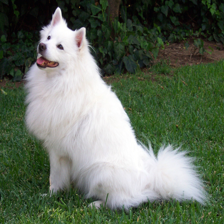

In [ ]:
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"

# 직접 이미지 파일을 반환하는 URL에서 이미지를 받아 RGB 형식으로 변환한 뒤 224x224로 맞춘다.
image = Image.open(BytesIO(requests.get(url).content)).convert("RGB").resize((224, 224))

print(f"이미지 크기: {image.size}")
image



이 단계에서 확인할 점:

- 이미지가 정상적으로 표시되는가?
- 크기가 `(224, 224)`로 맞춰졌는가?

### Step 2. 패치 분할 과정을 시각화하기

이제 이미지 위에 패치 격자를 그려서, ViT가 이미지를 어떤 단위로 나누는지 눈으로 확인한다.

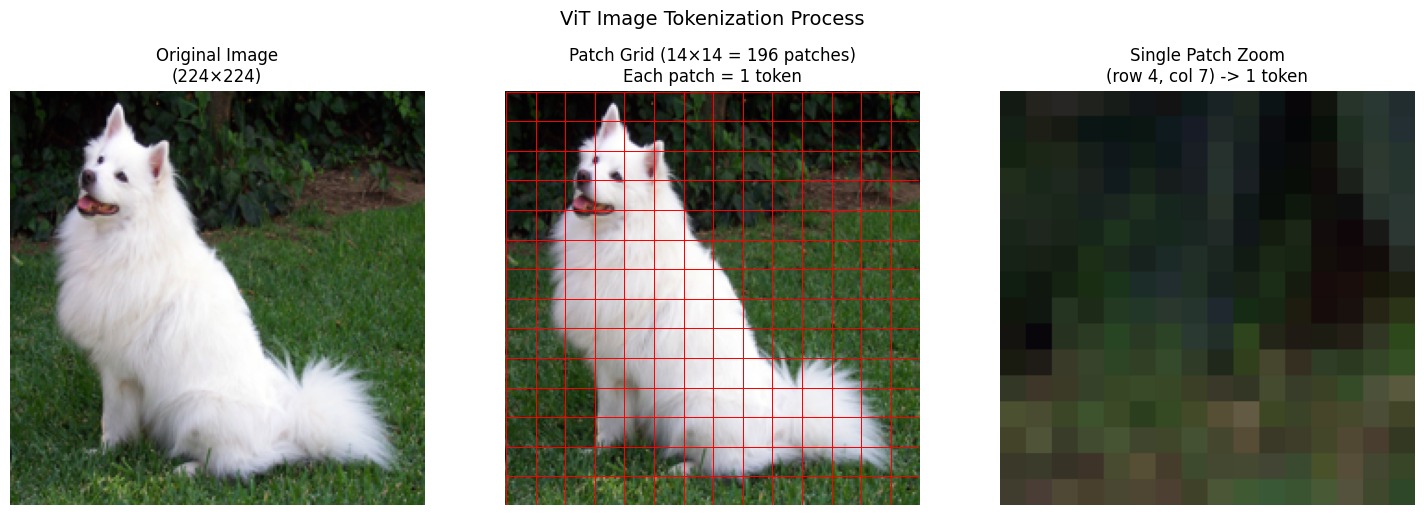

In [ ]:
PATCH_SIZE = 16
N = 224 // PATCH_SIZE  # 14

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 원본 이미지
axes[0].imshow(image)
axes[0].set_title("Original Image\n(224×224)", fontsize=12)
axes[0].axis("off")

# 패치 격자 오버레이
axes[1].imshow(image)
for row in range(N):
  for col in range(N):
    rect = patches.Rectangle(
      (col * PATCH_SIZE, row * PATCH_SIZE),
      PATCH_SIZE,
      PATCH_SIZE,
      linewidth=0.7,
      edgecolor="red",
      facecolor="none",
    )
    axes[1].add_patch(rect)

axes[1].set_title(f"Patch Grid ({N}×{N} = {N*N} patches)\nEach patch = 1 token", fontsize=12)
axes[1].axis("off")

# 단일 패치 확대
patch_row, patch_col = 4, 7
y1 = patch_row * PATCH_SIZE
x1 = patch_col * PATCH_SIZE
patch_img = image.crop((x1, y1, x1 + PATCH_SIZE, y1 + PATCH_SIZE))
patch_enlarged = patch_img.resize((224, 224), Image.NEAREST)

axes[2].imshow(patch_enlarged)
axes[2].set_title(f"Single Patch Zoom\n(row {patch_row}, col {patch_col}) -> 1 token", fontsize=12)
axes[2].axis("off")

plt.suptitle("ViT Image Tokenization Process", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

이 단계에서 확인할 점:

- 이 그림은 왼쪽에서 오른쪽으로 순서대로 읽으면 된다. 첫 번째 그림은 원본 이미지이고, 두 번째 그림은 그 이미지 위에 ViT가 자르는 패치 격자를 덮어쓴 모습이며, 세 번째 그림은 그중 패치 1개를 크게 확대한 모습이다.
- 가운데 그림의 빨간 격자는 `16×16` 크기의 패치 경계를 뜻한다. 224×224 이미지를 16으로 나누면 가로 14칸, 세로 14칸이 나오므로 전체는 `14×14 = 196`개 패치가 된다.
- 여기서 중요한 점은 가운데 그림의 **한 칸이 곧 패치 토큰 1개**라는 것이다. 즉, 텍스트에서 단어 하나가 토큰 하나가 되듯이, ViT에서는 이 작은 사각형 하나가 입력 단위 하나가 된다.
- 오른쪽 그림은 `(row 4, col 7)` 위치의 패치 하나를 크게 늘려 보여 준 것이다. 실제로는 매우 작은 `16×16` 이미지 조각이지만, 눈으로 확인하기 쉽도록 크게 확대해서 보여 주는 것이라고 이해하면 된다.
- 그래서 오른쪽 그림이 흐릿하고 픽셀처럼 보이는 것은 이상한 것이 아니다. 오히려 이것이 "패치 하나는 아주 작은 지역 정보만 담고 있다"는 사실을 잘 보여 준다. 모델은 이런 작은 조각 196개를 함께 보고 전체 이미지를 이해한다.
- 따라서 이 단계의 핵심은 "ViT는 이미지를 한 번에 보는 것이 아니라, 작은 패치들의 시퀀스로 잘라서 읽는다"는 점을 그림으로 확인하는 것이다.

### Step 3. ViT 모델로 실제 임베딩 추출하기

이번 단계에서는 시각화 수준을 넘어, 실제 ViT 모델이 이 이미지를 어떤 텐서 shape로 변환하는지 확인한다.

In [ ]:
print("\n[ViT 모델 임베딩 추출]")

processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
# 최근 transformers 환경에서는 attention map을 안정적으로 받기 위해 eager attention 구현을 명시하는 편이 안전하다.
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224", attn_implementation="eager")
vit_model.eval()

# 이미지를 모델 입력 텐서(pixel_values)로 변환
pixel_values = processor(images=image, return_tensors="pt").pixel_values

with torch.no_grad():
  outputs = vit_model(pixel_values, output_attentions=True)

hs = outputs.last_hidden_state

print(f"출력 shape: {hs.shape}")
print(f"  → (batch={hs.shape[0]}, 토큰수={hs.shape[1]}, 차원={hs.shape[2]})")
print(f"  → 첫 토큰 = [CLS], 나머지 {hs.shape[1]-1}개 = 패치 토큰")


[ViT 모델 임베딩 추출]


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


출력 shape: torch.Size([1, 197, 768])
  → (batch=1, 토큰수=197, 차원=768)
  → 첫 토큰 = [CLS], 나머지 196개 = 패치 토큰


이 단계에서 확인할 점:

- `torch.Size([1, 197, 768])`는 순서대로 `batch=1`, `토큰 수=197`, `임베딩 차원=768`이라고 읽는다. 즉, 이미지 1장을 넣었고, 그 이미지가 197개의 토큰 벡터로 바뀌었으며, 각 토큰은 길이 768의 벡터로 표현되었다는 뜻이다.
- 여기서 `1`은 이미지 개수다. 지금은 이미지 한 장만 넣었기 때문에 `batch=1`이 나온다. 만약 이미지를 4장 한꺼번에 넣었다면 이 값은 4가 되었을 것이다.
- `197`이 중요한 이유는, 앞 단계에서 본 `14×14 = 196`개 패치에 더해 맨 앞에 `[CLS]` 토큰 1개가 추가되기 때문이다. 즉, `197 = 1개 [CLS] + 196개 패치 토큰`으로 이해하면 된다.
- `[CLS]` 토큰은 이미지 전체를 대표하는 특별한 토큰이다. 반면 나머지 196개는 실제 이미지 패치 조각들에 대응하는 토큰이다. 그래서 ViT는 "전체 대표 토큰 1개 + 패치 토큰들"의 형태로 입력 시퀀스를 구성한다.
- 마지막의 `768`은 토큰 하나를 표현하는 벡터 길이, 즉 임베딩 차원이다. 다시 말해, 각 패치가 단순한 작은 이미지 조각으로 끝나는 것이 아니라, 모델이 계산할 수 있는 길이 768의 숫자 벡터로 바뀌었다는 뜻이다.
- 따라서 이 단계의 핵심은 "이미지가 2차원 픽셀 격자에서 끝나는 것이 아니라, 최종적으로는 197개의 벡터 시퀀스로 변환되어 Transformer에 들어간다"는 점을 shape로 확인하는 것이다.

### Step 4. 해상도별 토큰 수와 Attention 비용 계산하기

이제 입력 해상도가 바뀌면 토큰 수와 연산량이 어떻게 늘어나는지 숫자로 확인한다.

In [ ]:
print("\n[해상도별 토큰 수 및 연산 비율 (patch_size=16)]")
print(f"{'해상도':<12} {'토큰 수':>8} {'토큰 비율':>10} {'Attention 연산':>16}")
print("-" * 50)

base_tokens = (224 // 16) ** 2

for resolution in [224, 336, 448, 560, 672]:
  n_tokens = (resolution // 16) ** 2
  token_ratio = n_tokens / base_tokens
  attn_ratio = token_ratio ** 2

  print(f"{resolution}×{resolution}  →  {n_tokens:>5}개   {token_ratio:>7.2f}×    {attn_ratio:>12.1f}×")


[해상도별 토큰 수 및 연산 비율 (patch_size=16)]
해상도              토큰 수      토큰 비율     Attention 연산
--------------------------------------------------
224×224  →    196개      1.00×             1.0×
336×336  →    441개      2.25×             5.1×
448×448  →    784개      4.00×            16.0×
560×560  →   1225개      6.25×            39.1×
672×672  →   1764개      9.00×            81.0×


이 단계에서 확인할 점:

- 이 표는 "이미지 해상도가 커질수록 ViT(Vision Transformer)가 처리해야 하는 패치 토큰 수가 얼마나 늘어나는지"를 숫자로 보여준다. 패치 크기(`patch_size`)가 16으로 고정되어 있으므로, 해상도가 커지면 이미지를 더 많은 16×16 조각으로 잘라야 하고, 그만큼 토큰 수도 늘어난다.
- 기준은 `224×224` 해상도다. 이때 `14×14 = 196`개 패치가 만들어지므로 토큰 수가 196개가 된다. 표의 `토큰 비율 1.00×`와 `Attention 연산 1.0×`는 이 값을 기준점으로 삼았다는 뜻이다.
- 예를 들어 `336×336`에서는 패치 개수가 `21×21 = 441`개가 된다. 즉, 토큰 수가 `196개 → 441개`로 늘어나므로 약 `2.25배`가 된다. 여기까지는 "이미지 조각 수가 늘었다"고 이해하면 된다.
- 그런데 Attention 연산은 토큰을 하나씩 따로 보는 것이 아니라, "각 토큰이 다른 모든 토큰과 얼마나 관련 있는지"를 비교한다. 그래서 토큰 수가 `2.25배`가 되면 연산량은 대략 `2.25^2 = 5.1배`처럼 제곱에 가깝게 커진다.
- 이 때문에 해상도가 더 올라가면 부담이 급격히 커진다. 예를 들어 `448×448`는 토큰 수가 `4배`이지만 Attention 연산은 `16배`, `672×672`는 토큰 수가 `9배`인데 Attention 연산은 `81배`까지 증가한다. 즉, 해상도 증가는 단순히 "조금 더 선명해진다" 수준이 아니라 계산 비용을 매우 크게 키운다.
- 따라서 이 단계의 핵심은 "ViT에서 입력 해상도를 높이면 더 자세한 정보를 볼 수는 있지만, 그 대가로 토큰 수와 Attention 계산량이 매우 빠르게 증가한다"는 점을 표에서 읽어내는 것이다. 실무에서는 정확도 향상과 계산 비용 사이에서 적절한 해상도를 타협해야 한다.

### Step 5. ViT Attention Map 시각화하기

마지막으로, ViT가 이미지의 어떤 패치 영역에 더 주목하는지 heatmap과 오버레이로 확인한다.


[ViT Attention Map 시각화]


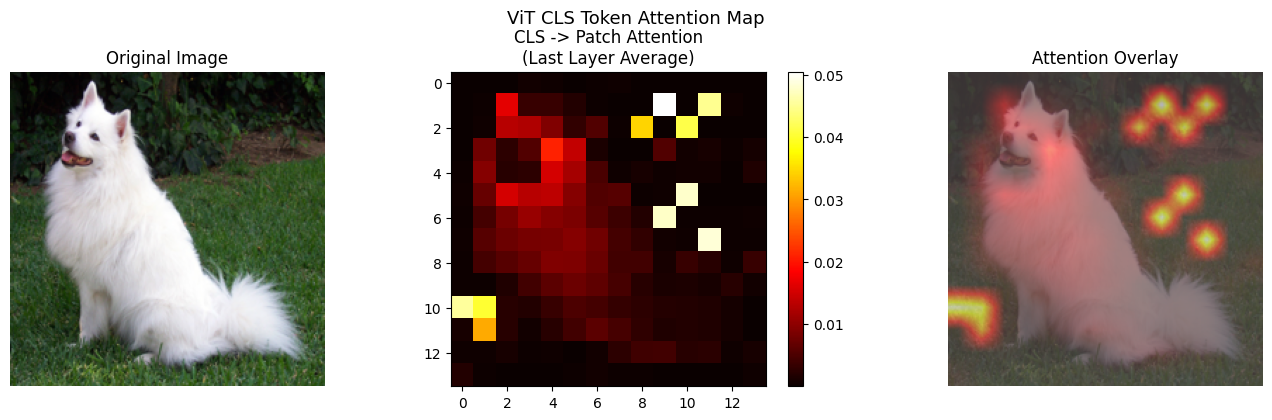

In [ ]:
print("\n[ViT Attention Map 시각화]")

if outputs.attentions is None:
  raise ValueError(
    "outputs.attentions is None입니다. Step 3 셀을 다시 실행해 outputs를 새로 만들고, "
    "ViTModel.from_pretrained(..., attn_implementation='eager')가 반영되었는지 확인하세요."
  )

# 마지막 레이어에서 CLS 토큰이 각 패치 토큰을 얼마나 보는지 추출
attn_last = outputs.attentions[-1][0]     # shape: (n_heads, 197, 197)
cls_attn = attn_last[:, 0, 1:]            # CLS → 패치 토큰 (n_heads, 196)
avg_attn = cls_attn.mean(dim=0).detach().numpy()
attn_map = avg_attn.reshape(14, 14)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

im = axes[1].imshow(attn_map, cmap="hot", interpolation="nearest")
axes[1].set_title("CLS -> Patch Attention\n(Last Layer Average)")
plt.colorbar(im, ax=axes[1])

# Attention map을 이미지 크기로 다시 늘려서 원본 위에 겹쳐 본다.
attn_resized = np.array(
  Image.fromarray((attn_map / attn_map.max() * 255).astype(np.uint8)).resize((224, 224), Image.BILINEAR)
)

axes[2].imshow(image, alpha=0.6)
axes[2].imshow(attn_resized, cmap="hot", alpha=0.5)
axes[2].set_title("Attention Overlay")
axes[2].axis("off")

plt.suptitle("ViT CLS Token Attention Map", fontsize=13)
plt.tight_layout()
plt.show()

이 단계에서 확인할 점:

- 이 결과는 왼쪽에서 오른쪽 순서로 읽으면 된다. 왼쪽은 원본 이미지, 가운데는 `14×14` 패치 단위의 Attention heatmap, 오른쪽은 그 Attention을 원본 이미지 위에 겹쳐 놓은 오버레이이다. 즉, 가운데의 밝은 칸이 오른쪽에서 어디에 해당하는지를 연결해서 보면 된다.
- 여기서 한 가지 더 중요한 점은, 이 그림이 마지막 레이어의 Attention Head 전체를 한 번에 보여 주는 것이 아니라는 점이다. `vit-base`의 마지막 레이어에는 Attention Head가 12개 있고, 현재 코드는 그 12개 head에서 나온 `CLS → 패치` attention 값을 평균내어 하나의 대표 map으로 만든다. 즉, 지금 보는 그림은 "12개의 시선을 하나로 요약한 평균 결과"라고 이해하면 된다.
- 가운데 heatmap에서 색이 밝을수록 `CLS` 토큰이 그 패치를 상대적으로 더 중요하게 보고 있다는 뜻이다. 완전히 흰색이나 노란색에 가까운 칸은 attention 값이 높은 곳이고, 어두운 붉은색이나 검은색에 가까울수록 상대적으로 덜 본 패치라고 이해하면 된다.
- 왜 평균을 내느냐 하면, head마다 보는 패턴이 조금씩 다르기 때문이다. 어떤 head는 윤곽을 더 보고, 어떤 head는 배경 단서를 더 볼 수 있다. 이를 각각 따로 보여 주면 초심자에게는 그림이 너무 많아지고 해석이 복잡해지므로, 먼저 전체적인 경향을 보기 위해 평균 map을 사용하는 것이다.
- 이 이미지에서는 강아지 몸통과 얼굴 주변에 비교적 넓게 붉은 영역이 퍼져 있다. 이것은 모델이 피사체 전체 윤곽과 주요 형태를 어느 정도 따라가며 보고 있다는 뜻으로 해석할 수 있다. 즉, ViT가 이미지를 무작위 패치 집합으로만 보는 것이 아니라, 의미 있는 객체 영역에도 주목하고 있음을 보여 준다.
- 동시에 오른쪽 위 배경 쪽이나 왼쪽 아래 일부 영역처럼 아주 밝은 점들이 보일 수 있다. 이것은 이상한 것이 아니다. Attention은 "정답 위치만 정확히 칠하는 분할 지도"가 아니라, 현재 표현을 만들 때 상대적으로 참고한 패치의 가중치를 보여 주는 것이기 때문이다. 그래서 피사체 외의 배경 패치에도 높은 값이 일부 나타날 수 있다.
- 오른쪽 오버레이 그림에서는 붉거나 노랗게 겹쳐진 부분이 모델이 더 주목한 위치다. 이 그림을 볼 때는 "정확히 한 점만 보는가"보다도, "강아지 주변의 어떤 영역들과 배경의 어떤 부분들에 반응이 모이는가"를 큰 흐름으로 읽는 것이 중요하다.
- 따라서 이 단계의 핵심은 "ViT의 Attention은 이미지를 패치 단위로 살펴보면서, 특히 의미 있는 객체 주변과 일부 배경 단서를 함께 참고해 전체 이미지를 이해한다"는 점을 시각적으로 확인하는 것이다. 즉, Attention Map은 모델의 시선을 완벽하게 설명하는 정답표가 아니라, 어떤 패치들이 상대적으로 더 중요하게 반영되었는지를 보여 주는 힌트로 읽으면 된다.

### 실습을 마친 뒤 정리

위 실습이 끝나면 아래 내용을 말로 설명할 수 있어야 한다.

1. ViT는 이미지를 패치 토큰 시퀀스로 바꿔 Transformer에 넣는다.
2. 224×224 이미지는 patch size 16일 때 196개 패치 토큰이 된다.
3. `[CLS]` 토큰까지 포함하면 입력 길이는 197이 된다.
4. 해상도가 커지면 토큰 수가 늘고, Attention 비용은 더 빠르게 증가한다.
5. ViT Attention Map을 보면 모델이 어떤 이미지 영역을 더 중요하게 보는지 관찰할 수 있다.

**관찰 과제**

1. Attention Map에서 어떤 패치 영역이 가장 강조되는지 확인 (피사체 vs 배경)
2. 해상도를 672×672로 올리면 Attention 연산량이 몇 배 증가하는지 계산
3. 동적 고해상도(2×2 타일)를 적용하면 총 토큰 수가 얼마나 되는지 계산

---

## 핵심 개념 정리

```
이미지 → 패치 분할 → 선형 투영 → 패치 토큰 시퀀스
  ↓
Transformer Encoder가 텍스트 토큰과 동일한 방식으로 처리

핵심 제약:
  고해상도 ↑ → 토큰 수 ↑ → Attention 연산 O(n²) 폭발
  이것이 동적 고해상도(타일 분할)가 필요한 이유
```

### 혼자 점검하기

아래 질문에 막힘 없이 답하면 이론 이해가 잘 된 것이다.

1. ViT가 이미지를 텍스트처럼 처리할 수 있는 이유는 무엇인가?
2. $224 \times 224$ 이미지를 $16 \times 16$ 패치로 나누면 왜 196개 토큰이 생기는가?
3. 해상도가 2배가 되면 Attention 비용은 왜 16배가 되는가?
4. 썸네일과 타일을 함께 쓰는 동적 고해상도 전략의 장점은 무엇인가?
5. 문서 OCR이나 UI 이해에서 고해상도가 특히 중요한 이유는 무엇인가?

---

## 다음 교시 예고

**7교시(마무리)**: 1일차 핵심 개념 정리

---

## 부록 | 관찰 과제·혼자 점검 모범 답안

이 부록은 교육생이 실습과 이론을 마친 뒤 스스로 이해를 점검할 수 있도록 만든 해설이다.  
정답을 그대로 외우기보다, **시각화 결과와 수치 계산을 보고 왜 그런 해석이 나오는지 설명할 수 있는지**를 기준으로 활용하면 된다.

### 관찰 과제 모범 답안

**1. Attention Map에서 어떤 패치 영역이 가장 강조되는지 확인 (피사체 vs 배경)**

일반적으로 ViT의 Attention Map은 배경 전체보다 피사체나 특징적인 구조가 있는 영역에 더 높은 값을 보이는 경향이 있다. 물론 모델과 이미지에 따라 완벽하게 피사체만 강조되는 것은 아니지만, 의미 있는 객체 영역이나 윤곽 주변에 더 많은 attention이 모이는 경우가 많다. 이 관찰을 통해 ViT가 이미지를 무작위 패치 집합으로 보는 것이 아니라, 중요한 시각 정보를 가진 영역에 더 집중할 수 있다는 점을 이해할 수 있다.

**2. 해상도를 672×672로 올리면 Attention 연산량이 몇 배 증가하는지 계산**

224×224가 기준일 때 672×672는 가로와 세로가 각각 3배이므로, 패치 수는 $3^2 = 9$배가 된다. Attention 연산은 토큰 수의 제곱에 비례하므로 $9^2 = 81$배가 된다. 즉, 해상도를 3배 올리면 Attention 비용은 81배까지 커질 수 있다.

**3. 동적 고해상도(2×2 타일)를 적용하면 총 토큰 수가 얼마나 되는지 계산**

예를 들어 448×448 타일 하나를 16×16 패치로 나누면 $28 \times 28 = 784$개 패치 토큰이 생긴다. 2×2 타일이면 타일이 4개이므로 $784 \times 4 = 3136$개 패치 토큰이 된다. 여기에 전체 썸네일(224×224)까지 함께 넣으면 196개 패치 토큰이 추가된다. 즉, 총 패치 토큰 수는 3332개 수준이 된다. 실제 모델은 여기에 `[CLS]`나 특수 토큰 구조가 더해질 수 있지만, 핵심은 동적 고해상도가 전체 보기와 세부 보기를 함께 하기 위해 토큰 수를 크게 늘린다는 점이다.

### 혼자 점검하기 모범 답안

**1. ViT가 이미지를 텍스트처럼 처리할 수 있는 이유는 무엇인가?**

ViT는 이미지를 작은 패치들로 나누고, 각 패치를 하나의 임베딩 벡터로 바꿔 시퀀스로 만든다. 즉, 텍스트에서 토큰 임베딩 시퀀스를 만들듯이, 이미지에서도 패치 임베딩 시퀀스를 만든다. 그래서 Transformer가 텍스트를 처리하듯이 이미지를 처리할 수 있다.

**2. $224 \times 224$ 이미지를 $16 \times 16$ 패치로 나누면 왜 196개 토큰이 생기는가?**

가로 방향으로는 $224 / 16 = 14$, 세로 방향으로도 $224 / 16 = 14$개의 패치가 생긴다. 전체 패치 수는 $14 \times 14 = 196$개다. 즉, 2차원 이미지를 동일한 크기의 격자로 나눴을 때 생기는 총 칸 수가 곧 패치 토큰 수가 된다.

**3. 해상도가 2배가 되면 Attention 비용은 왜 16배가 되는가?**

가로와 세로가 각각 2배가 되면 이미지 면적은 4배가 된다. 패치 크기가 같다면 패치 수, 즉 토큰 수도 4배가 된다. Attention 연산은 토큰 수의 제곱에 비례하므로, $4^2 = 16$배가 된다. 따라서 해상도 2배 증가는 연산량 16배 증가로 이어진다.

**4. 썸네일과 타일을 함께 쓰는 동적 고해상도 전략의 장점은 무엇인가?**

썸네일은 이미지 전체 맥락을 빠르게 파악하게 해 주고, 타일은 작은 글씨나 세부 구조를 정밀하게 보게 해 준다. 즉, 전체 구조 이해와 지역 세부 인식을 동시에 할 수 있다는 것이 가장 큰 장점이다. 이 방식은 모든 이미지를 무조건 초고해상도로 넣는 것보다 효율적이다.

**5. 문서 OCR이나 UI 이해에서 고해상도가 특히 중요한 이유는 무엇인가?**

문서와 UI는 작은 글자, 가는 선, 아이콘, 숫자 차이처럼 미세한 시각 정보가 의미를 크게 바꾸는 경우가 많다. 해상도가 낮으면 이런 디테일이 뭉개져서 읽기 어려워진다. 따라서 OCR, 표 읽기, 버튼 인식, 수식 해석 같은 작업에서는 고해상도 입력이 특히 중요하다.

### 활용 팁

이 부록은 아래 순서로 복습할 때 가장 효과적이다.

1. 먼저 패치 격자 그림과 Attention Map을 보고 스스로 해석해 본다.
2. 그다음 모범 답안과 비교한다.
3. 숫자가 조금 달라도 계산 원리와 핵심 개념이 맞으면 이해한 것으로 본다.
4. 설명이 막히면 다시 패치 수 계산과 해상도별 토큰 수 표를 확인한다.